In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import sys
sys.path.insert(0, '../')  # adjust based on where your notebook is
from scripts.download_data import get_clinical_patient_data, get_clinical_sample_data
sns.set_theme(style='whitegrid', context='paper')


In [43]:
STUDY_ID = "luad_mskcc_2023_met_organotropism"
clinical_patient= get_clinical_patient_data(STUDY_ID)
clinical_sample = get_clinical_sample_data(STUDY_ID)



[4/4] Downloading patient-level clinical data...
   ✓ 2298 patients × 33 columns

[3/4] Downloading sample-level clinical data...
   ✓ 2653 samples × 60 columns


In [47]:
clinical_sample['patientId'] = clinical_sample['sampleId'].str.extract(r'(P-\d+)') # get the patient id from sample id
df = pd.merge(clinical_patient, clinical_sample, how='inner', on='patientId')
df = df[df['GROUP_NO'].isin(['Group1', 'Group2'])]


In [48]:
target_cols = ['EVER_MET_SITE_ADRENAL', 'EVER_MET_SITE_BONE', 'EVER_MET_SITE_CNS',
               'EVER_MET_SITE_LIVER_BILIARY_TRACT', 'EVER_MET_SITE_LN', 
               'EVER_MET_SITE_LUNG', 'EVER_MET_SITE_PLEURA']

df['TMB_NONSYNONYMOUS'] = df['TMB_NONSYNONYMOUS'].astype(float)

df[target_cols] = df[target_cols].astype(int)


df['EVER_MET'] = (df[target_cols].sum(axis=1) > 0).astype(int)


In [ ]:
df.columns


Index(['patientId', 'ADJUVANT', 'ADJUVANT_CHEMOTHERAPY',
       'ADJUVANT_IMMUNOTHERAPY', 'ADJUVANT_TARGETED', 'ADJUVANT_XRT',
       'ADRENAL_MONTHS', 'ADRENAL_STATUS', 'BONE_MONTHS', 'BONE_STATUS',
       'CIGARETTE_HX', 'CNS_MONTHS', 'CNS_STATUS', 'HAD_SURGERY',
       'LIVER_MONTHS', 'LIVER_STATUS', 'LN_MONTHS', 'LN_STATUS', 'LUNG_MONTHS',
       'LUNG_STATUS', 'MONTHS_FROM_MATCHED_PRIM', 'NEOADJUVANT',
       'NEOADJUVANT_CHEMOTHERAPY', 'NEOADJUVANT_IMMUNOTHERAPY',
       'NEOADJUVANT_TARGETED', 'NEOADJUVANT_XRT', 'OS_MONTHS', 'OS_STATUS',
       'PLEURA_MONTHS', 'PLEURA_STATUS', 'RACE', 'SAMPLE_COUNT', 'SEX',
       'sampleId', 'ADJUVANT_THERAPY', 'AGE_AT_DOS_BX', 'CANCER_TYPE',
       'CANCER_TYPE_DETAILED', 'CELL_CYCLE', 'CSTAGE', 'DEATH',
       'EVER_MET_SITE_ADRENAL', 'EVER_MET_SITE_BONE', 'EVER_MET_SITE_CNS',
       'EVER_MET_SITE_LIVER_BILIARY_TRACT', 'EVER_MET_SITE_LN',
       'EVER_MET_SITE_LUNG', 'EVER_MET_SITE_PLEURA', 'FGA',
       'FRACTION_GENOME_ALTERED', 'FU_2YRS'

In [53]:
print(df['RACE'].describe())


count       576
unique        5
top       White
freq        472
Name: RACE, dtype: object


In [54]:
472/576


0.8194444444444444

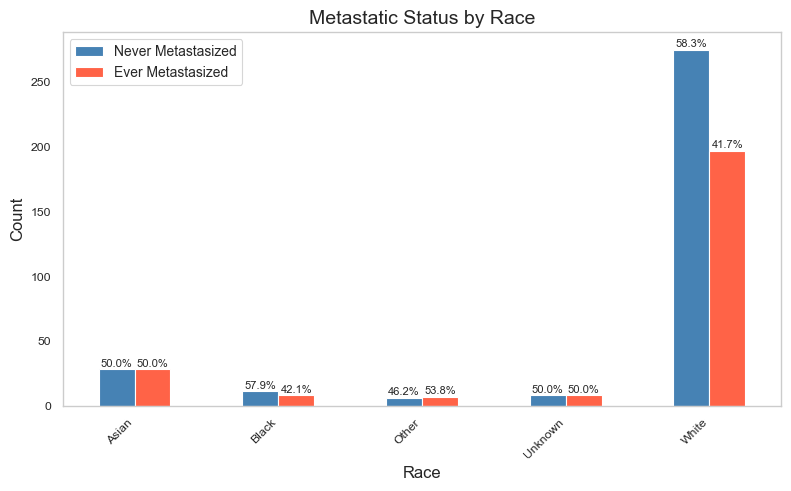

In [52]:
fig, ax = plt.subplots(figsize=(8, 5))
race_met = df.groupby(['RACE', 'EVER_MET']).size().unstack(fill_value=0)
race_met.columns = ['Never Metastasized', 'Ever Metastasized']
race_met.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])

# add percentage labels
totals = race_met.sum(axis=1)
for container in ax.containers:
    for bar, (race, total) in zip(container, totals.items()):
        height = bar.get_height()
        if height > 0:
            pct = height / total * 100
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                   f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Race', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Metastatic Status by Race', fontsize=14)
ax.legend(fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(False)
plt.savefig('../results/figures/race_distribution.png', dpi=300)
plt.show()


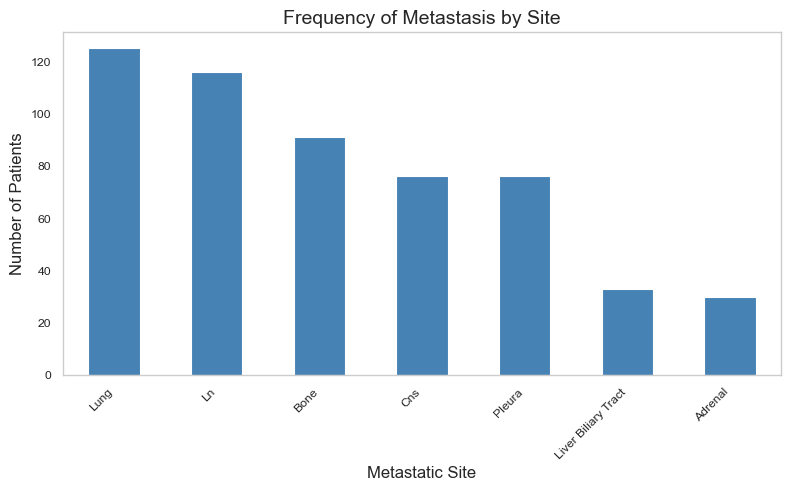

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
label_counts = df[target_cols].sum().sort_values(ascending=False)
label_counts.index = [col.replace('EVER_MET_SITE_', '').replace('_', ' ').title() 
                      for col in label_counts.index]
label_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Metastatic Site', fontsize=12)
ax.set_ylabel('Number of Patients', fontsize=12)
ax.set_title('Frequency of Metastasis by Site', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(False)
plt.savefig('../results/figures/label_frequency.png', dpi=300)
plt.show()


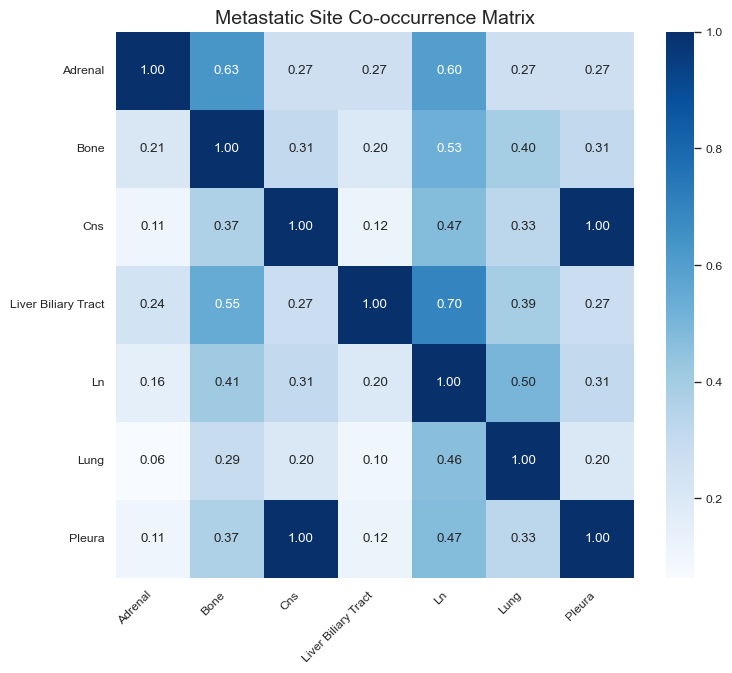

In [12]:
# co-occurence matrix
import numpy as np

fig, ax = plt.subplots(figsize=(8, 7))

# compute co-occurrence matrix
cooccurrence = df[target_cols].T.dot(df[target_cols])
cooccurrence_norm = cooccurrence.div(cooccurrence.values.diagonal(), axis=0)
# clean up labels
labels = [col.replace('EVER_MET_SITE_', '').replace('_', ' ').title() 
          for col in target_cols]

sns.heatmap(cooccurrence_norm, 
            annot=True, 
            fmt='.2f',
            xticklabels=labels,
            yticklabels=labels,
            cmap='Blues',
            ax=ax)

ax.set_title('Metastatic Site Co-occurrence Matrix', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
ax.set_xlabel('')
ax.set_ylabel('')
plt.savefig('../results/figures/cooccurrence_heatmap.png', dpi=300)
plt.show()


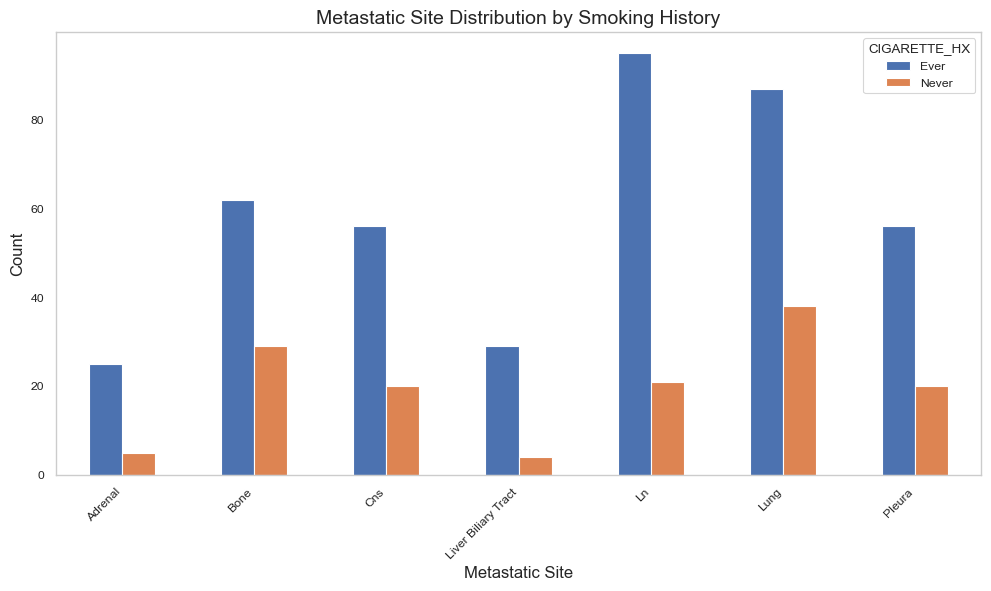

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

df_g2 = df[df['GROUP_NO'] == 'Group2']
smoking_site = df_g2.groupby('CIGARETTE_HX')[target_cols].sum()
smoking_site.columns = [col.replace('EVER_MET_SITE_', '').replace('_', ' ').title() 
                        for col in target_cols]

smoking_site.T.plot(kind='bar', ax=ax)
ax.set_xlabel('Metastatic Site', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Metastatic Site Distribution by Smoking History', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(False)
plt.savefig('../results/figures/smoking_by_site.png', dpi=300)
plt.show()


/var/folders/nt/gz5b2xbd7sl05982064yjtx00000gn/T/ipykernel_82782/1669745737.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([never_met, ever_met], labels=['Never Metastasized', 'Ever Metastasized'],


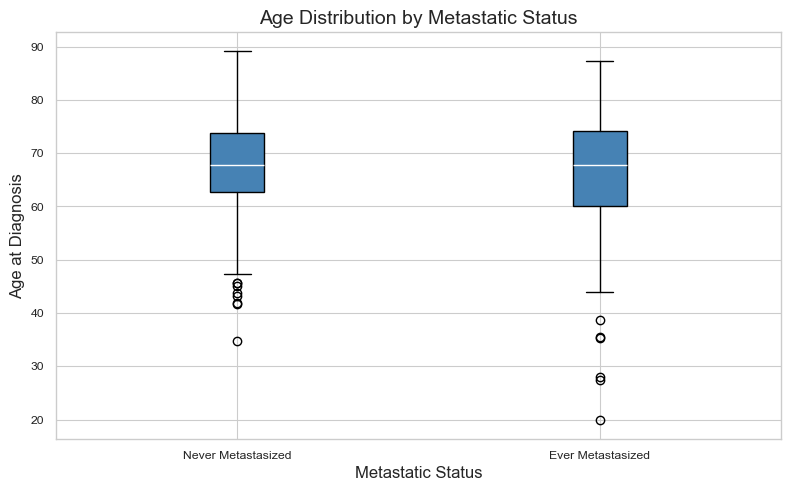

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

never_met = df[df['EVER_MET_LABEL'] == 'Never Metastasized']['AGE_AT_DOS_BX'].dropna()
ever_met = df[df['EVER_MET_LABEL'] == 'Ever Metastasized']['AGE_AT_DOS_BX'].dropna()

never_met = never_met.astype(float)
ever_met = ever_met.astype(float)

ax.boxplot([never_met, ever_met], labels=['Never Metastasized', 'Ever Metastasized'],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue'),
           medianprops=dict(color='white'))

ax.set_xlabel('Metastatic Status', fontsize=12)
ax.set_ylabel('Age at Diagnosis', fontsize=12)
ax.set_title('Age Distribution by Metastatic Status', fontsize=14)
plt.tight_layout()
plt.show()


In [59]:
import joblib
import pandas as pd

# load
clf_logistic = joblib.load('../models/fitted_models/clinical/gridsearch_logistic_ridge.pkl')
clf_rf = joblib.load('../models/fitted_models/clinical/gridsearch_random_forest.pkl')
clf_svm = joblib.load('../models/fitted_models/clinical/gridsearch_SVM.pkl')

# extract cv results
lr_cv = pd.DataFrame(clf_logistic.cv_results_)
rf_cv = pd.DataFrame(clf_rf.cv_results_)
svm_cv = pd.DataFrame(clf_svm.cv_results_)


In [60]:
print(lr_cv.columns.tolist())


['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_estimator__C', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score']


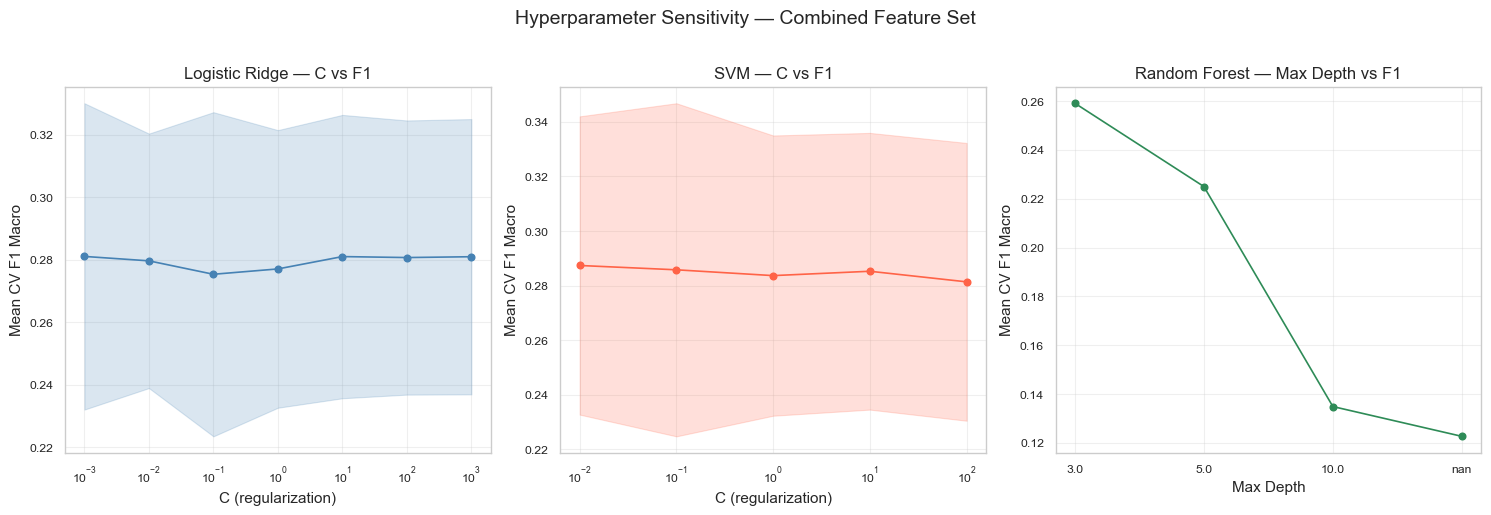

In [61]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Logistic Ridge - C vs F1
ax = axes[0]
ax.plot(lr_cv['param_estimator__C'], lr_cv['mean_test_score'], 'o-', color='steelblue')
ax.fill_between(lr_cv['param_estimator__C'],
                lr_cv['mean_test_score'] - lr_cv['std_test_score'],
                lr_cv['mean_test_score'] + lr_cv['std_test_score'],
                alpha=0.2, color='steelblue')
ax.set_xscale('log')
ax.set_xlabel('C (regularization)', fontsize=11)
ax.set_ylabel('Mean CV F1 Macro', fontsize=11)
ax.set_title('Logistic Ridge — C vs F1', fontsize=12)
ax.grid(alpha=0.3)

# SVM - C vs F1
ax = axes[1]
ax.plot(svm_cv['param_estimator__C'], svm_cv['mean_test_score'], 'o-', color='tomato')
ax.fill_between(svm_cv['param_estimator__C'],
                svm_cv['mean_test_score'] - svm_cv['std_test_score'],
                svm_cv['mean_test_score'] + svm_cv['std_test_score'],
                alpha=0.2, color='tomato')
ax.set_xscale('log')
ax.set_xlabel('C (regularization)', fontsize=11)
ax.set_ylabel('Mean CV F1 Macro', fontsize=11)
ax.set_title('SVM — C vs F1', fontsize=12)
ax.grid(alpha=0.3)

# Random Forest - max_depth vs F1
rf_grouped = rf_cv.groupby('param_estimator__max_depth', dropna=False)['mean_test_score'].mean()
ax = axes[2]
ax.plot(range(len(rf_grouped)), rf_grouped.values, 'o-', color='seagreen')
ax.set_xticks(range(len(rf_grouped)))
ax.set_xticklabels([str(v) for v in rf_grouped.index])
ax.set_xlabel('Max Depth', fontsize=11)
ax.set_ylabel('Mean CV F1 Macro', fontsize=11)
ax.set_title('Random Forest — Max Depth vs F1', fontsize=12)
ax.grid(alpha=0.3)

plt.suptitle('Hyperparameter Sensitivity — Combined Feature Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/hyperparameter_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()
